---
# # Data Cleaning Model for Removing Missing Values and Noisy data
| Step | What we do |
|------|------------|
| 1 | Load the Data  |
| 2 | Find the Missing Values |
| 3 | Drop the Noisy Columns |
| 4 | Fix missing values |
| 5 | Handle outliers |
| 6 | Final data Check and Save |

---
## Step 1 — Load the Data 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/kaggle/input/datasets/abdallaahmed77/healthcare-risk-factors-dataset/dirty_v3_path.csv')
print('Rows and Columns:', df.shape)
df.head(10)

Rows and Columns: (30000, 20)


,Age,Gender,Medical Condition,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours,random_notes,noise_col
0,46.0,Male,Diabetes,137.04,135.27,28.90,96.04,6,231.88,210.56,7.61,0,0,-0.20,3.54,0,5.07,6.05,lorem,-137.057211
1,22.0,Male,Healthy,71.58,113.27,26.29,97.54,2,165.57,129.41,4.91,0,0,8.12,5.90,0,5.87,7.72,ipsum,-11.230610
2,50.0,NaN,Asthma,95.24,NaN,22.53,90.31,2,214.94,165.35,5.60,0,0,5.01,4.65,1,3.09,4.82,ipsum,98.331195
3,57.0,NaN,Obesity,NaN,130.53,38.47,96.60,5,197.71,182.13,6.92,0,0,3.16,3.37,0,3.01,5.33,lorem,44.187175
4,66.0,Female,Hypertension,95.15,178.17,31.12,94.90,4,259.53,115.85,5.98,0,1,3.56,3.40,0,6.38,6.64,lorem,44.831426
5,50.0,Male,Hypertension,107.00,171.80,25.33,95.21,5,233.10,203.67,5.48,1,0,5.01,4.65,0,7.25,6.35,ipsum,108.411983
6,80.0,Male,Hypertension,NaN,174.52,29.87,97.96,3,247.11,128.27,5.99,1,1,1.92,5.76,1,8.25,7.23,ipsum,7.009539
7,50.0,Male,Cancer,NaN,136.13,26.37,82.72,19,209.26,137.79,6.23,1,0,5.34,3.34,0,8.76,4.94,###,64.247308
8,60.0,Female,Obesity,NaN,NaN,35.49,98.62,3,264.69,194.21,6.83,0,0,1.66,2.99,0,5.93,5.87,lorem,45.855558
9,13.0,Female,Asthma,90.60,126.88,29.24,97.96,6,193.44,163.65,6.18,1,0,5.27,5.63,0,7.09,5.41,lorem,-45.916696


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                25500 non-null  float64
 1   Gender             25500 non-null  object 
 2   Medical Condition  25500 non-null  object 
 3   Glucose            25500 non-null  float64
 4   Blood Pressure     25500 non-null  float64
 5   BMI                30000 non-null  float64
 6   Oxygen Saturation  30000 non-null  float64
 7   LengthOfStay       30000 non-null  int64  
 8   Cholesterol        30000 non-null  float64
 9   Triglycerides      30000 non-null  float64
 10  HbA1c              30000 non-null  float64
 11  Smoking            30000 non-null  int64  
 12  Alcohol            30000 non-null  int64  
 13  Physical Activity  30000 non-null  float64
 14  Diet Score         30000 non-null  float64
 15  Family History     30000 non-null  int64  
 16  Stress Level       300

---
## Step 2 — Find the Missing Values

In [5]:
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Values': missing_count,
    'Percentage (%)': missing_percent
})
missing_report[missing_report['Missing Values'] > 0]

,Missing Values,Percentage (%)
Age,4500,15.0
Gender,4500,15.0
Medical Condition,4500,15.0
Glucose,4500,15.0
Blood Pressure,4500,15.0


---
## Step 3 — Drop the Noisy Columns

We identified two junk columns: `random_notes` and `noise_col`.

In [6]:
columns_to_drop = ['random_notes', 'noise_col']
print('Columns before:',  df.shape[1])
df = df.drop(columns=columns_to_drop)
print('Columns after :', df.shape[1])
print()
print('Remaining columns:')
print(list(df.columns))
print()
df.head()

Columns before: 20
Columns after : 18

Remaining columns:
['Age', 'Gender', 'Medical Condition', 'Glucose', 'Blood Pressure', 'BMI', 'Oxygen Saturation', 'LengthOfStay', 'Cholesterol', 'Triglycerides', 'HbA1c', 'Smoking', 'Alcohol', 'Physical Activity', 'Diet Score', 'Family History', 'Stress Level', 'Sleep Hours']



,Age,Gender,Medical Condition,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours
0,46.0,Male,Diabetes,137.04,135.27,28.90,96.04,6,231.88,210.56,7.61,0,0,-0.20,3.54,0,5.07,6.05
1,22.0,Male,Healthy,71.58,113.27,26.29,97.54,2,165.57,129.41,4.91,0,0,8.12,5.90,0,5.87,7.72
2,50.0,NaN,Asthma,95.24,NaN,22.53,90.31,2,214.94,165.35,5.60,0,0,5.01,4.65,1,3.09,4.82
3,57.0,NaN,Obesity,NaN,130.53,38.47,96.60,5,197.71,182.13,6.92,0,0,3.16,3.37,0,3.01,5.33
4,66.0,Female,Hypertension,95.15,178.17,31.12,94.90,4,259.53,115.85,5.98,0,1,3.56,3.40,0,6.38,6.64


---
## Step 4 — Fix Missing Values

We have two types of columns with missing data:

- **Text columns** (Gender, Medical Condition) → we will fill it with the **most common value** (called the mode)
- **Number columns** (Age, Glucose, Blood Pressure) → we will fill it with the **middle value** (called the median)

**Why median and not mean for numbers?** The mean gets pulled by extreme outlier values. The median is always the actual middle of the data, so it's more reliable.
**Why mode for text?** You can't calculate an average of words, so we use the most frequently occurring category instead.

In [7]:
text_columns_with_missing = ['Gender', 'Medical Condition']

for column in text_columns_with_missing:
    most_common_value = df[column].mode()[0]
    df[column] = df[column].fillna(most_common_value)
    print(f'{column} column filled with: "{most_common_value}"')

Gender column filled with: "Female"
Medical Condition column filled with: "Hypertension"


In [8]:
number_columns_with_missing = ['Age', 'Glucose', 'Blood Pressure']

for column in number_columns_with_missing:
    median_value = df[column].median()
    df[column] = df[column].fillna(median_value)
    print(f'{column} column filled with median: {median_value:.2f}')

Age column filled with median: 55.00
Glucose column filled with median: 110.50
Blood Pressure column filled with median: 138.32


In [9]:
total_missing_left = df.isnull().sum().sum()
print(f'Total missing values left: {total_missing_left}')

Total missing values left: 0


---
## Step 5 — Handle Outliers

### IQR (Interquartile Range)

### How IQR works:

Imagine sorting all the values in a column from smallest to largest.
- **Q1** = the value at the 25% mark
- **Q3** = the value at the 75% mark
- **IQR** = Q3 minus Q1 (the middle 50% of the data)

Anything below `Q1 - 1.5 × IQR` or above `Q3 + 1.5 × IQR` is considered an outlier.

Instead of deleting outliers (which wastes data), we **cap** them — meaning we replace extreme values with the boundary value.

### Boxplot
- The **box** covers the middle 50% of the data (Q1 to Q3)
- The **red line** inside the box is the median
- The **whiskers** extend to the IQR boundary
- Any **dots** beyond the whiskers are outliers

In [10]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

print('Numeric columns we will check for outliers:')
print(numeric_columns)

Numeric columns we will check for outliers:
['Age', 'Glucose', 'Blood Pressure', 'BMI', 'Oxygen Saturation', 'LengthOfStay', 'Cholesterol', 'Triglycerides', 'HbA1c', 'Smoking', 'Alcohol', 'Physical Activity', 'Diet Score', 'Family History', 'Stress Level', 'Sleep Hours']


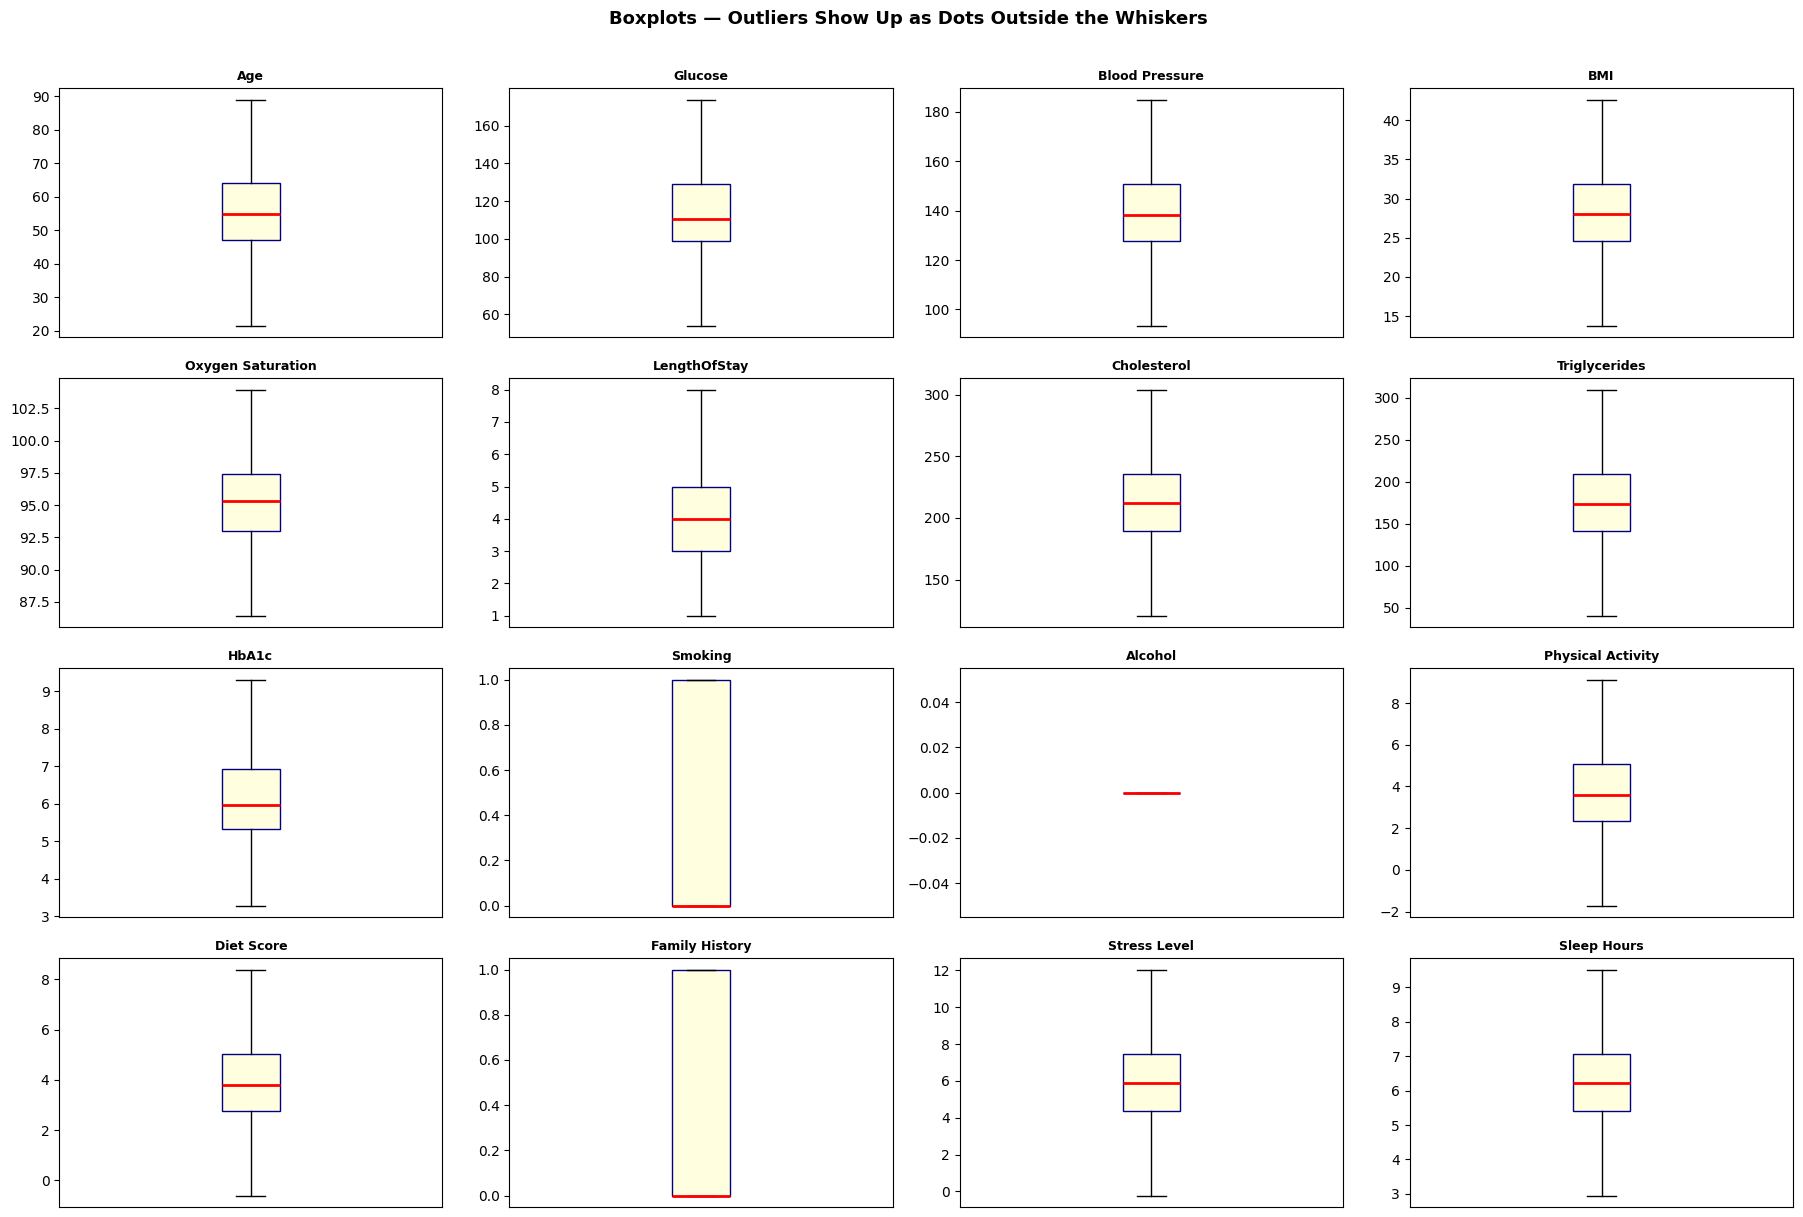

In [18]:
fig, axes = plt.subplots(4, 4, figsize=(18, 12))
axes = axes.flatten()

for i, column in enumerate(numeric_columns):
    axes[i].boxplot(df[column].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightyellow', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(column, fontweight='bold', fontsize=9)
    axes[i].set_xticks([])

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Boxplots — Outliers Show Up as Dots Outside the Whiskers', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [12]:
def cap_outliers_with_iqr(dataframe, columns):
    
    dataframe = dataframe.copy()
    outlier_summary = []
    
    for column in columns:
        Q1 = dataframe[column].quantile(0.25)
        Q3 = dataframe[column].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_boundary = Q1 - 1.5 * IQR
        upper_boundary = Q3 + 1.5 * IQR
        
        number_of_outliers = ((dataframe[column] < lower_boundary) | (dataframe[column] > upper_boundary)).sum()
        
        dataframe[column] = dataframe[column].clip(lower=lower_boundary, upper=upper_boundary)
        
        outlier_summary.append({
            'Column': column,
            'Lower Boundary': round(lower_boundary, 2),
            'Upper Boundary': round(upper_boundary, 2),
            'Outliers Capped': number_of_outliers
        })
    
    return dataframe, pd.DataFrame(outlier_summary)


df, outlier_report = cap_outliers_with_iqr(df, numeric_columns)

outlier_report

,Column,Lower Boundary,Upper Boundary,Outliers Capped
0,Age,21.50,89.50,748
1,Glucose,53.84,173.89,3667
2,Blood Pressure,93.38,184.98,820
3,BMI,13.76,42.64,552
4,Oxygen Saturation,86.43,103.95,898
5,LengthOfStay,0.00,8.00,1246
6,Cholesterol,120.78,304.02,186
7,Triglycerides,40.26,309.65,286
8,HbA1c,2.94,9.30,1051
9,Smoking,-1.50,2.50,0


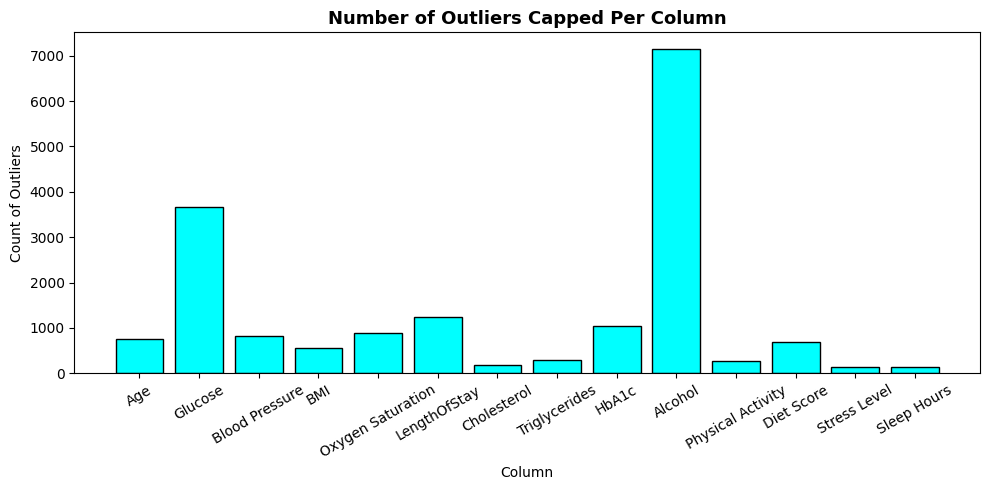

In [15]:
plt.figure(figsize=(10, 5))
outliers_found = outlier_report[outlier_report['Outliers Capped'] > 0]
plt.bar(outliers_found['Column'], outliers_found['Outliers Capped'], color='cyan', edgecolor='black')
plt.title('Number of Outliers Capped Per Column', fontsize=13, fontweight='bold')
plt.ylabel('Count of Outliers')
plt.xlabel('Column')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---
## Step 6 — Final Data Check and Save

In [16]:

print('FINAL DATA QUALITY CHECK')
print(f'Rows           : {df.shape[0]}')
print(f'Columns        : {df.shape[1]}')
print(f'Missing Values : {df.isnull().sum().sum()}')
print(f'Duplicate Rows : {df.duplicated().sum()}')

FINAL DATA QUALITY CHECK
Rows           : 30000
Columns        : 18
Missing Values : 0
Duplicate Rows : 0


In [17]:
df.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
Age,54.789133,14.437541,21.500,89.000
Glucose,117.481146,28.530804,53.845,173.885
Blood Pressure,139.923449,18.791183,93.380,184.980
BMI,28.431356,5.585046,13.760,42.640
Oxygen Saturation,95.041434,3.438783,86.430,103.950
LengthOfStay,4.164867,1.970537,1.000,8.000
Cholesterol,212.979418,33.316136,120.785,304.025
Triglycerides,176.667685,48.137589,40.255,309.655
HbA1c,6.273291,1.262175,3.280,9.305
Smoking,0.279767,0.448892,0.000,1.000


In [ ]:
df.to_csv('cleaned_medical_data.csv', index=False)

print('Your cleaned dataset has been saved as: cleaned_medical_data.csv')
print(f'It has {df.shape[0]} rows and {df.shape[1]} columns — ready to use!')